# Setup

In [1]:
!pip install -q datasets transformers evaluate accelerate
!pip install -q "ray[tune]" scipy sklearn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.3/474.3 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
 

In [2]:
!pip -q install lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 35.6 MB/s eta 0:00:00


In [3]:
import os, sys
import pickle
from time import gmtime, strftime
from tqdm.notebook import tqdm  # Progress bar

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy as sp

import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch.utilities import CombinedLoader
from sklearn.metrics import f1_score, classification_report

from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, AutoModel, AutoConfig
from transformers import DebertaV2Config, DebertaV2Model, DebertaV2PreTrainedModel
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer
from transformers import get_scheduler


In [4]:
'''Set-up GPU for use'''

gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Some operations on a GPU are implemented stochastic for efficiency
# Ensure that all operations are deterministic on GPU for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Is the GPU available? True
Device cuda


# Prepare Datasets

In [ ]:
#ucc_train_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_train_no_scores.csv'
ucc_test_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_test_no_scores.csv'
ucc_train_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_train_confident_no_scores.csv'
#ucc_test_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/ucc_test_confident_no_sarcasm.csv'

reddit_train_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/reddit_train_balanced.csv'
reddit_test_filename = '/content/drive/My Drive/Colab Notebooks/AISI_project/data/reddit_test_balanced.csv'

In [ ]:
# Get max length of text in UCC dataset
df = pd.read_csv(ucc_train_filename)
text_column = df['comment']
max_length_ucc = np.max(np.array([len(comment) for comment in text_column]))
print('UCC max length: ', max_length_ucc)

# Get max length of text in reddit dataset
df = pd.read_csv(reddit_train_filename)
text_column = df['text']
max_length_reddit = np.max(np.array([len(text) for text in text_column]))
print('Reddit max length: ', max_length_reddit)

UCC max length:  349
Reddit max length:  36239


In [ ]:
max_length = 1000

# Tokenize data

In [ ]:
def preprocess_ucc(example):
    '''Method for preprocessing the UCC dataset'''

    # Gather list of positive labels
    all_labels = []
    for class_ in classes:
        if example[class_] == 1:
            all_labels.append(class_)

    # Convert labels to a vector of binary values
    labels = [0.0 for i in range(len(classes))]
    for label in all_labels:
        label_id = class2id[label]
        labels[label_id] = 1

    example = tokenizer(example['comment'], padding='max_length', truncation=True)
    example['labels'] = labels

    return example

def preprocess_reddit(example):

    if example['labels'] == 'abuse':
        example['labels'] = 1.0
    elif example['labels'] == 'non_abuse':
        example['labels'] = 0.0
    else:
        sys.error(1)

    example = tokenizer(example['text'], padding='max_length', truncation=True)
    return example


ucc = load_dataset('csv', data_files={'train': ucc_train_filename, 'test': ucc_test_filename})
reddit = load_dataset('csv', data_files={'train': reddit_train_filename, 'test': reddit_test_filename})

# Dicts for the UCC dataset to convert between class name and class numerical id
classes = [class_ for class_ in list(ucc['train'].features)[1:] if class_]
class2id = {class_:id for id, class_ in enumerate(classes)}
id2class = {id:class_ for class_, id in class2id.items()}
# Dicts for the Reddit dataset to convert between class name and binary label
class2binary = {'abuse': 1, 'non_abuse': 0}
binary2class = {1:'abuse', 0:'non_abuse'}

# Tokenize Data
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small', model_max_length=max_length, use_fast=False)
tokenized_ucc = ucc.map(preprocess_ucc)
tokenized_reddit = reddit.map(preprocess_reddit)

# Delete class columns from reddit dataset now that we represent the labels as vecs
tokenized_ucc = tokenized_ucc.remove_columns(classes)


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/882 [00:00<?, ? examples/s]

Map:   0%|          | 0/4425 [00:00<?, ? examples/s]

Map:   0%|          | 0/2281 [00:00<?, ? examples/s]

Map:   0%|          | 0/410 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_ucc, '\n')
print(tokenized_reddit)

DatasetDict({
    train: Dataset({
        features: ['comment', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 882
    })
    test: Dataset({
        features: ['comment', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4425
    })
}) 

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2281
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 410
    })
})


## Get abuse and non-abuse examples for inference

In [ ]:
abuse_ex1 = tokenized_reddit['test'][3]['text']
abuse_ex2 = tokenized_reddit['test'][6]['text']
custom_manipulation_ex = "my partner asked me for my phone password. i didn't want to give it to them so I said no. they then asked me what I was hiding and that if I really loved them I would give them my password"
custom_manipulation_dialogue = "give me your password. what do you have to hide? if you really loved me you'd give it to me"
custom_isolation_ex = "my girlfriend took my phone and unfollowed all of my friends on social media. she also changed my tiktok password. i think she is just joking around but my friend told me that it was weird and that I should be careful"
custom_belittling_ex = "my boyfriend asked me why I posted this one pic. he said that I look really desperate for likes and that the pic is not flattering"
custom_belittling_dialogue = "why did you post this? ngl you look really desperate for likes. this pic is not flattering"
custom_belittling_ex2 = "my husband told me I looked ugly today"
custom_belittling_dialogue2 = "you look really ugly today"

nonabuse_ex1 = tokenized_reddit['test'][205]['text']
nonabuse_ex2 = tokenized_reddit['test'][207]['text']
nonabuse_ex3 = tokenized_reddit['test'][300]['text']
custom_nonabuse = 'Yesterday my girlfriend and I celebrated our anniversary and she took me to my favorite spot for dinner! i love her so much!'

inference_examples = [abuse_ex1, abuse_ex2, custom_manipulation_ex, custom_manipulation_dialogue, custom_isolation_ex, custom_belittling_ex, custom_belittling_dialogue, custom_belittling_ex2, custom_belittling_dialogue2, nonabuse_ex1, nonabuse_ex2, nonabuse_ex3, custom_nonabuse]

### Finetuning model in native pytorch:

In [ ]:
# To prepare the tokenized datasets for training in native pytorch, do the following:

# The model does not accept raw text as an input. Remove the 'comment' and 'text' columns:
tokenized_ucc = tokenized_ucc.remove_columns(['comment'])
tokenized_reddit = tokenized_reddit.remove_columns(['text'])

# Set the format of the dataset to return PyTorch tensors instead of lists:
tokenized_ucc.set_format('torch')
tokenized_reddit.set_format('torch')

# Split the tokenized data into train, test, and validation
ucc_train_dataset = tokenized_ucc['train'].shuffle(seed=6)
ucc_eval_dataset = tokenized_ucc['test'].shuffle(seed=6)
reddit_train_dataset = tokenized_reddit['train'].shuffle(seed=6)
reddit_eval_dataset = tokenized_reddit['test'].shuffle(seed=6)

# Note: pytorch requires the label column to be named 'labels'. Change if needed.

# Define Model Class

In [5]:
class MTLTextClassification(nn.Module):
    def __init__(self, llm, activation=nn.LeakyReLU()):
        super(MTLTextClassification, self).__init__()

        self.llm = llm
        self.activation = activation

        self.feature_extractor = torch.nn.Sequential(
            nn.Dropout(p=0.2),
            torch.nn.Linear(768, 64),
            torch.nn.LeakyReLU(),
        )

        self.reddit_out = torch.nn.Linear(64, 1)
        self.ucc_out = torch.nn.Linear(64, 5)

    def forward(self, input_ids, token_type_ids, attention_mask, taskid):
        # Get embedding from the LLM we are tuning. Use last hidden state of embedding for classification tasks.
        x = self.llm(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask)
        x = x["last_hidden_state"][:,0,:]

        # Extract shared features for both tasks
        features = self.feature_extractor(x)

        # Branch on task
        if taskid == 1:
            logits = self.ucc_out(features)     # Get output for task 1: UCC classification (BCEWithLogitsLoss)
        elif taskid == 2:
            logits = self.reddit_out(features)  # Get output for task 2: Abuse/Non-abuse classification (BCEWithLogitsLoss)

        return logits


# Loading Trained Models and their Results

In [52]:
all_train_results = []
all_test_results = []

In [53]:
def load_saved_model(model_file, llm_file, train_results_file, test_results_file):
    # load LLM
    llm_state_dict = torch.load(llm_file)
    saved_llm = AutoModel.from_pretrained('microsoft/deberta-v3-small')
    saved_llm.load_state_dict(llm_state_dict)
    # load model
    state_dict = torch.load(model_file)
    saved_mtl_model = MTLTextClassification(llm=saved_llm)
    saved_mtl_model.load_state_dict(state_dict)

    # load training and testing results
    with open(train_results_file, 'rb') as handle:
        train_results = pickle.load(handle)
    with open(test_results_file, 'rb') as handle:
        test_results = pickle.load(handle)

    return saved_mtl_model, saved_llm, train_results, test_results

## MTL: eta=1.0 and standard UCC

In [54]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_Apr29_01_05_21.tar'
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_Apr29_01_05_21.tar'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_Apr29_01_05_21.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_Apr29_01_05_21.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

<ipython-input-53-beeb0c8df49b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  llm_state_dict = torch.load(llm_file)
<ipython-input-53-beeb0c8df49b>:7: FutureWarning: You 

In [55]:
# Convert tensors to scalars
epoch_losses= []
for epoch_list in train_results['loss_per_epoch']:
    losses = [loss.item() for loss in epoch_list]
    epoch_losses.append(losses)
train_results['loss_per_epoch'] = epoch_losses

epoch_losses= []
for epoch_list in train_results['reddit_losses']:
    losses = [loss.item() for loss in epoch_list]
    epoch_losses.append(losses)
train_results['reddit_losses'] = epoch_losses

epoch_losses= []
for epoch_list in train_results['ucc_losses']:
    losses = [loss.item() for loss in epoch_list]
    epoch_losses.append(losses)
train_results['ucc_losses'] = epoch_losses

epoch_accs = []
for acc in train_results['total_accs']:
    epoch_accs.append(acc.item())
print(epoch_accs)
train_results['total_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['reddit_accs']:
    epoch_accs.append(acc.item())
train_results['reddit_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['ucc_accs']:
    epoch_accs.append(acc.item())
train_results['ucc_accs'] = epoch_accs

[0.774605393409729, 0.8174326419830322, 0.8417478799819946, 0.8659470677375793, 0.8849233984947205]


In [56]:
all_train_results.append(train_results)
all_test_results.append(test_results)

print(train_results['loss_per_epoch'])
print('\n', train_results['reddit_losses'])
print('\n', train_results['ucc_losses'])
print('\n', train_results['total_accs'])
print('\n', train_results['reddit_accs'])
print('\n', train_results['ucc_accs'])

[[1.7545897960662842, 1.6096364259719849, 1.363072156906128, 1.2188351154327393, 1.2449958324432373, 1.1977031230926514, 1.1889240741729736, 1.0116809606552124, 1.13966703414917, 0.9940071105957031, 1.0065622329711914, 1.003246784210205, 1.071671724319458, 0.889421284198761, 0.9188063144683838, 0.9163652658462524, 0.98914635181427, 0.734753429889679, 0.8159230947494507, 0.8584526181221008, 0.813751220703125, 0.7227810621261597, 0.8174946904182434, 0.7546257972717285, 0.7279844284057617, 0.7447086572647095, 0.7881414890289307, 0.7788791060447693, 0.734224259853363, 0.7449648380279541, 0.6243736743927002, 0.7751684784889221, 0.7023205757141113, 0.7260809540748596, 0.7383280992507935, 0.6424949169158936, 0.6769682765007019, 0.799917459487915, 0.6419557332992554, 0.6583490371704102, 0.6549176573753357, 0.6360217332839966, 0.6803708076477051, 0.6753286719322205, 0.6419440507888794, 0.6356667876243591, 0.7079523801803589, 0.6864835619926453, 0.6974765062332153, 0.6900294423103333, 0.61162239

### Plot Loss and Accuracy for this model


In [ ]:
avg_loss = [np.mean(epoch_list) for epoch_list in train_results['loss_per_epoch']]
avg_ucc_loss = [np.mean(epoch_list) for epoch_list in train_results['ucc_losses']]
avg_reddit_loss = [np.mean(epoch_list) for epoch_list in train_results['reddit_losses']]

In [ ]:
print('Avg Total Loss per epoch: ', avg_loss)
print('Avg UCC Loss per epoch: ', avg_ucc_loss)
print('Avg Reddit Loss per epoch: ', avg_reddit_loss)
print('Avg Total Accuracy per epoch: ', train_results['total_accs'])
print('Avg Reddit Accuracy per epoch: ', train_results['reddit_accs'])
print('Avg UCC Accuracy per epoch: ', train_results['ucc_accs'])

Avg Total Loss per epoch:  [0.5711955144420308, 0.48779892740890507, 0.44745068272840344, 0.3859867925721955, 0.3372209755013746]
Avg UCC Loss per epoch:  [0.5431711162572783, 0.47218488264714775, 0.4294433863548183, 0.3751587827267089, 0.3314308812296988]
Avg Reddit Loss per epoch:  [0.02802439796278502, 0.015614044560381525, 0.018007294886938783, 0.010828009564500862, 0.005790093880192789]
Avg Total Accuracy per epoch:  [0.774605393409729, 0.8174326419830322, 0.8417478799819946, 0.8659470677375793, 0.8849233984947205]
Avg Reddit Accuracy per epoch:  [0.992688000202179, 0.9951253533363342, 0.9940807819366455, 0.9972144961357117, 0.9982590079307556]
Avg UCC Accuracy per epoch:  [0.7309888601303101, 0.7818941473960876, 0.8112813830375671, 0.8396936058998108, 0.8622562885284424]


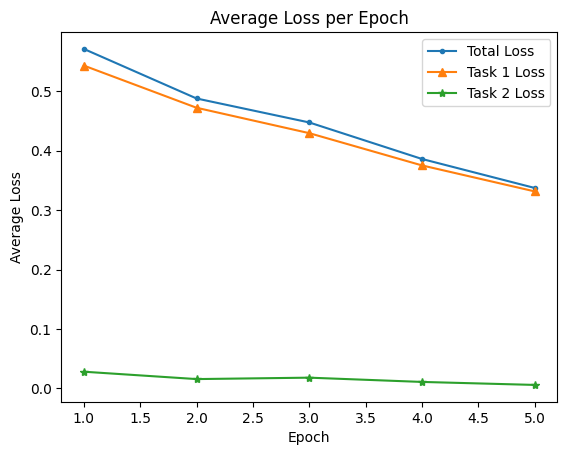

In [ ]:
num_epochs = 5
plt.plot(np.arange(1,6,1), avg_loss, label='Total Loss', marker='.')
plt.plot(np.arange(1,6,1), avg_ucc_loss, marker='^', label='Task 1 Loss')
plt.plot(np.arange(1,6,1), avg_reddit_loss, marker='*', label='Task 2 Loss')
plt.legend()
plt.title('Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()

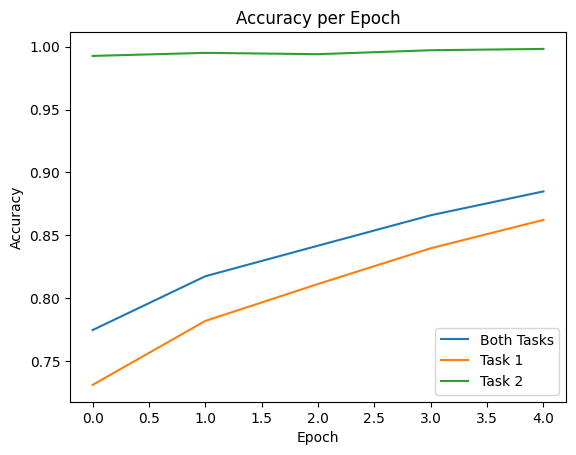

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), train_results['total_accs'], label='Both Tasks')
plt.plot(np.arange(num_epochs), train_results['ucc_accs'], label='Task 1')
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

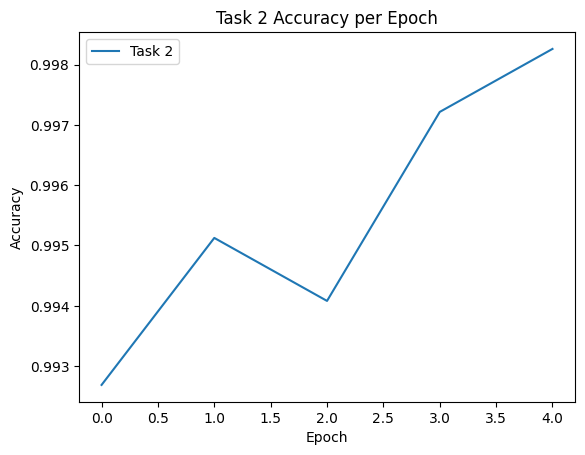

In [ ]:
# Zoom in on Reddit Accuracy
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Task 2 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## MTL: eta=0.4 and standard UCC

In [57]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_40-60.tar'
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_40-60'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_eta_40_60.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_eta_40_60.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

<ipython-input-53-beeb0c8df49b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  llm_state_dict = torch.load(llm_file)
<ipython-input-53-beeb0c8df49b>:7: FutureWarning: You 

In [58]:
# Convert tensors to scalars
epoch_accs = []
for acc in train_results['total_accs']:
    epoch_accs.append(acc.item())
train_results['total_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['reddit_accs']:
    epoch_accs.append(acc.item())
train_results['reddit_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['ucc_accs']:
    epoch_accs.append(acc.item())
train_results['ucc_accs'] = epoch_accs

In [59]:
all_train_results.append(train_results)
all_test_results.append(test_results)

print(train_results['loss_per_epoch'])
print('\n', train_results['reddit_losses'])
print('\n', train_results['ucc_losses'])
print('\n', train_results['total_accs'])
print('\n', train_results['reddit_accs'])
print('\n', train_results['ucc_accs'])

[[0.6086761951446533, 0.6486025452613831, 0.6801856160163879, 0.748833417892456, 0.7718822956085205, 0.9109484553337097, 0.8494808673858643, 0.757574200630188, 0.7123316526412964, 0.8199599385261536, 0.7031368017196655, 0.763049304485321, 0.6893277764320374, 0.6182796955108643, 0.740433931350708, 0.6753842830657959, 0.7404396533966064, 0.7177831530570984, 0.6657497882843018, 0.6610180139541626, 0.7082980871200562, 0.6892408132553101, 0.6220683455467224, 0.6933385133743286, 0.7150771617889404, 0.6931293606758118, 0.6849974393844604, 0.6538553237915039, 0.70318603515625, 0.7104436159133911, 0.6779683232307434, 0.6792400479316711, 0.7463012933731079, 0.6998318433761597, 0.6762129068374634, 0.6872743368148804, 0.6617398262023926, 0.7344286441802979, 0.6414852142333984, 0.6298782229423523, 0.6571323275566101, 0.6697869300842285, 0.6328471899032593, 0.6683456897735596, 0.5694789290428162, 0.5996909141540527, 0.5377820730209351, 0.5375982522964478, 0.5030250549316406, 0.6266826391220093, 0.54

### Plot Loss and Accuracy for this model

In [ ]:
avg_loss = [np.mean(epoch_list) for epoch_list in train_results['loss_per_epoch']]
avg_ucc_loss = [np.mean(epoch_list) for epoch_list in train_results['ucc_losses']]
avg_reddit_loss = [np.mean(epoch_list) for epoch_list in train_results['reddit_losses']]

In [ ]:
print('Avg Total Loss per epoch: ', avg_loss)
print('Avg UCC Loss per epoch: ', avg_ucc_loss)
print('Avg Reddit Loss per epoch: ', avg_reddit_loss)
print('Avg Total Accuracy per epoch: ', train_results['total_accs'])
print('Avg Reddit Accuracy per epoch: ', train_results['reddit_accs'])
print('Avg UCC Accuracy per epoch: ', train_results['ucc_accs'])

Avg Total Loss per epoch:  [0.43497535739934545, 0.35231966324005287, 0.31566388919575966, 0.27265686002199363, 0.24047558387341939]
Avg UCC Loss per epoch:  [0.6735333341243871, 0.6655072052664743, 0.6471492472548339, 0.6057958035914015, 0.5560349985583579]
Avg Reddit Loss per epoch:  [0.2759366880266987, 0.14352795400028961, 0.09467363867922984, 0.05056422239595578, 0.03010263280297077]
Avg Total Accuracy per epoch:  [0.6375928521156311, 0.6584261655807495, 0.6826253533363342, 0.7283542156219482, 0.7679897546768188]
Avg Reddit Accuracy per epoch:  [0.8889275789260864, 0.9550835490226746, 0.9693593382835388, 0.9850278496742249, 0.9923397898674011]
Avg UCC Accuracy per epoch:  [0.587325930595398, 0.5990947484970093, 0.6252785921096802, 0.6770195364952087, 0.7231197953224182]


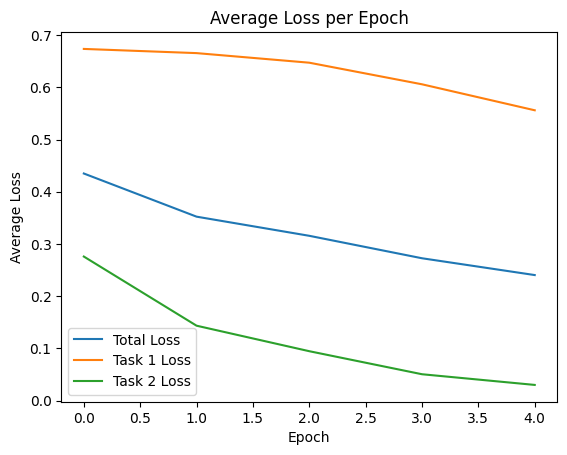

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), avg_loss, label='Total Loss')
plt.plot(np.arange(num_epochs), avg_ucc_loss, label='Task 1 Loss')
plt.plot(np.arange(num_epochs), avg_reddit_loss, label='Task 2 Loss')
plt.legend()
plt.title('Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()

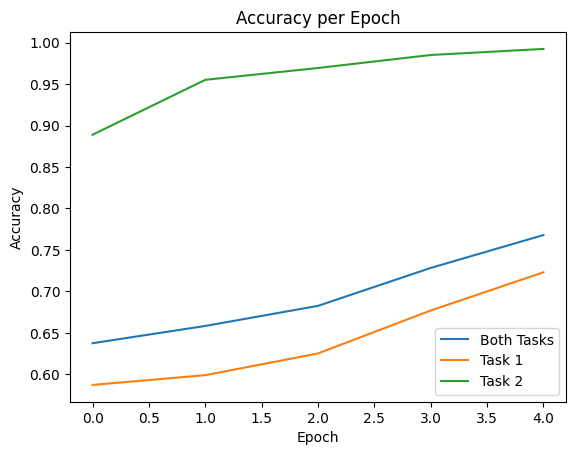

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), train_results['total_accs'], label='Both Tasks')
plt.plot(np.arange(num_epochs), train_results['ucc_accs'], label='Task 1')
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

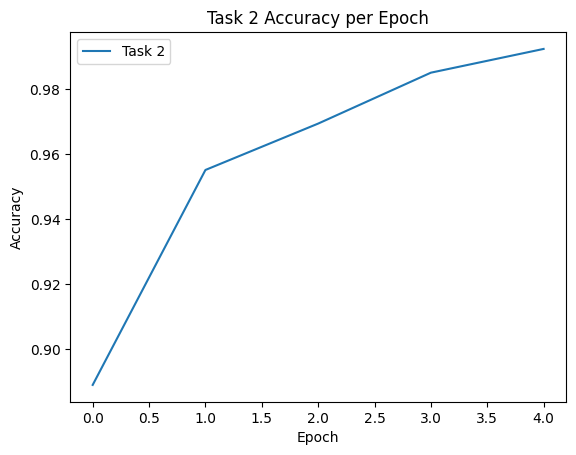

In [ ]:
# Zoom in on Reddit Accuracy
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Task 2 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## MTL: eta=0.6 and standard UCC

In [60]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_eta_60-40.tar'
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_eta_60-40'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_eta_60_40.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_eta_60_40.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

<ipython-input-53-beeb0c8df49b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  llm_state_dict = torch.load(llm_file)
<ipython-input-53-beeb0c8df49b>:7: FutureWarning: You 

In [61]:
# Convert tensors to scalars
epoch_accs = []
for acc in train_results['total_accs']:
    epoch_accs.append(acc.item())
train_results['total_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['reddit_accs']:
    epoch_accs.append(acc.item())
train_results['reddit_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['ucc_accs']:
    epoch_accs.append(acc.item())
train_results['ucc_accs'] = epoch_accs

In [62]:
all_train_results.append(train_results)
all_test_results.append(test_results)

print(train_results['loss_per_epoch'])
print('\n', train_results['reddit_losses'])
print('\n', train_results['ucc_losses'])
print('\n', train_results['total_accs'])
print('\n', train_results['reddit_accs'])
print('\n', train_results['ucc_accs'])

[[0.7069426774978638, 0.6543080806732178, 0.6742103695869446, 0.7126008868217468, 0.8201950788497925, 0.6857147216796875, 0.7179865837097168, 0.7072712182998657, 0.7048645615577698, 0.663116455078125, 0.7104303240776062, 0.6934717297554016, 0.6451055407524109, 0.7190845012664795, 0.6888838410377502, 0.6962758898735046, 0.6827365159988403, 0.6900244951248169, 0.6983343362808228, 0.6591881513595581, 0.6044331789016724, 0.7410582304000854, 0.6587064266204834, 0.7367001175880432, 0.8353716135025024, 0.7717888355255127, 0.7009034156799316, 0.7333819270133972, 0.6645972728729248, 0.7190404534339905, 0.6858048439025879, 0.6638083457946777, 0.6770220994949341, 0.6878421306610107, 0.7191583514213562, 0.674493670463562, 0.6934327483177185, 0.7055288553237915, 0.7228298187255859, 0.6830171346664429, 0.684468686580658, 0.6897373795509338, 0.6937066316604614, 0.6953556537628174, 0.6378359794616699, 0.750102698802948, 0.6699464321136475, 0.6861104369163513, 0.657863974571228, 0.6606788039207458, 0.7

### Plot Loss and Accuracy for this model

In [ ]:
avg_loss = [np.mean(epoch_list) for epoch_list in train_results['loss_per_epoch']]
avg_ucc_loss = [np.mean(epoch_list) for epoch_list in train_results['ucc_losses']]
avg_reddit_loss = [np.mean(epoch_list) for epoch_list in train_results['reddit_losses']]

In [ ]:
print('Avg Total Loss per epoch: ', avg_loss)
print('Avg UCC Loss per epoch: ', avg_ucc_loss)
print('Avg Reddit Loss per epoch: ', avg_reddit_loss)
print('Avg Total Accuracy per epoch: ', train_results['total_accs'])
print('Avg Reddit Accuracy per epoch: ', train_results['reddit_accs'])
print('Avg UCC Accuracy per epoch: ', train_results['ucc_accs'])

Avg Total Loss per epoch:  [0.5595098172306683, 0.4964344445875428, 0.4528194110954704, 0.41133303755588185, 0.37393231166936564]
Avg UCC Loss per epoch:  [0.6706223682938844, 0.6653381081344689, 0.648620713969127, 0.6080382577141016, 0.5727696742104953]
Avg Reddit Loss per epoch:  [0.392840942716833, 0.24307890492296857, 0.15911741768629978, 0.11627516823348623, 0.07567623275115536]
Avg Total Accuracy per epoch:  [0.6284238696098328, 0.649605393409729, 0.678737223148346, 0.7193012833595276, 0.7494776844978333]
Avg Reddit Accuracy per epoch:  [0.8172005414962769, 0.9129526019096375, 0.9526461958885193, 0.9651810526847839, 0.9770194888114929]
Avg UCC Accuracy per epoch:  [0.5906685590744019, 0.5969359278678894, 0.6239554286003113, 0.6701253652572632, 0.7039693593978882]


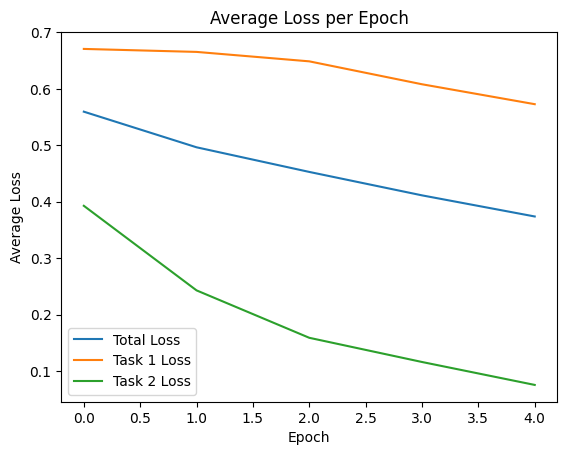

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), avg_loss, label='Total Loss')
plt.plot(np.arange(num_epochs), avg_ucc_loss, label='Task 1 Loss')
plt.plot(np.arange(num_epochs), avg_reddit_loss, label='Task 2 Loss')
plt.legend()
plt.title('Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()

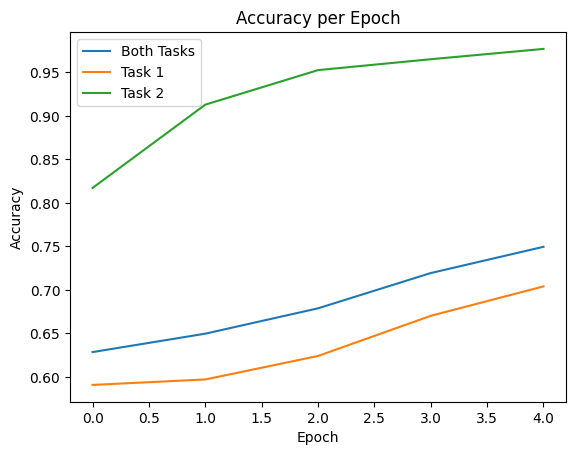

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), train_results['total_accs'], label='Both Tasks')
plt.plot(np.arange(num_epochs), train_results['ucc_accs'], label='Task 1')
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

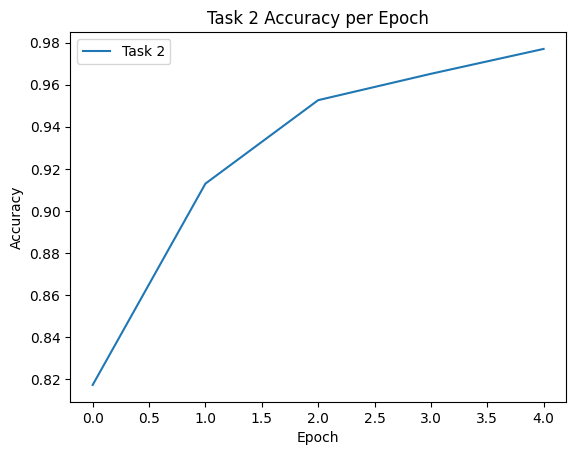

In [ ]:
# Zoom in on Reddit Accuracy
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Task 2 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## MTL: eta=1.0 and Confident UCC

In [63]:
# Load Model
llm_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/llm_confident.tar'         # default eta and confident ucc dataset
model_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/mtl_confident.tar'
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/results_confident.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/test_results_confident.pickle'
mtl_model, llm, train_results, test_results = load_saved_model(model_file, llm_file, train_file, test_file)

<ipython-input-53-beeb0c8df49b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  llm_state_dict = torch.load(llm_file)
<ipython-input-53-beeb0c8df49b>:7: FutureWarning: You 

In [64]:
# Convert tensors to scalars
epoch_accs = []
for acc in train_results['total_accs']:
    epoch_accs.append(acc.item())
train_results['total_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['reddit_accs']:
    epoch_accs.append(acc.item())
train_results['reddit_accs'] = epoch_accs

epoch_accs = []
for acc in train_results['ucc_accs']:
    epoch_accs.append(acc.item())
train_results['ucc_accs'] = epoch_accs

In [65]:
all_train_results.append(train_results)
all_test_results.append(test_results)

print(train_results['loss_per_epoch'])
print('\n', train_results['reddit_losses'])
print('\n', train_results['ucc_losses'])
print('\n', train_results['total_accs'])
print('\n', train_results['reddit_accs'])
print('\n', train_results['ucc_accs'])

[[1.5293803215026855, 1.3632006645202637, 1.5144875049591064, 1.5164031982421875, 1.2106566429138184, 1.2115418910980225, 1.4653613567352295, 1.2659642696380615, 1.3809281587600708, 1.3337279558181763, 1.3533549308776855, 1.4248416423797607, 1.3867428302764893, 1.5423641204833984, 1.4435398578643799, 1.4074432849884033, 1.289304494857788, 1.348731279373169, 1.3552772998809814, 1.3324559926986694, 1.3580858707427979, 1.3123114109039307, 1.3125245571136475, 1.461987018585205, 1.3090598583221436, 1.3166723251342773, 1.2182981967926025, 1.4385080337524414, 1.3188555240631104, 1.5216760635375977, 1.270942211151123, 1.1969852447509766, 1.2794322967529297, 1.268988013267517, 1.5550730228424072, 1.1256898641586304, 1.0565052032470703, 1.2616136074066162, 1.164578914642334, 1.056040644645691, 1.1422264575958252, 1.1600737571716309, 0.992695689201355, 0.8594146370887756, 0.7814602851867676, 1.3675532341003418, 1.275325894355774, 1.2728850841522217, 1.153009295463562, 1.1671290397644043, 0.939586

### Plot Loss and Accuracy for this model

In [ ]:
avg_loss = [np.mean(epoch_list) for epoch_list in train_results['loss_per_epoch']]
avg_ucc_loss = [np.mean(epoch_list) for epoch_list in train_results['ucc_losses']]
avg_reddit_loss = [np.mean(epoch_list) for epoch_list in train_results['reddit_losses']]

In [ ]:
print('Avg Total Loss per epoch: ', avg_loss)
print('Avg UCC Loss per epoch: ', avg_ucc_loss)
print('Avg Reddit Loss per epoch: ', avg_reddit_loss)
print('Avg Total Accuracy per epoch: ', train_results['total_accs'])
print('Avg Reddit Accuracy per epoch: ', train_results['reddit_accs'])
print('Avg UCC Accuracy per epoch: ', train_results['ucc_accs'])

Avg Total Loss per epoch:  [0.9250185154052206, 0.5900662162466768, 0.37365484792223747, 0.25479138103002213, 0.19135887188846717]
Avg UCC Loss per epoch:  [0.6416990008537907, 0.4648323115189731, 0.3034861578284755, 0.21043923956500252, 0.16613097566191348]
Avg Reddit Loss per epoch:  [0.2833195144503056, 0.12523390457683264, 0.07016869005828691, 0.04435214137572032, 0.025227896589867366]
Avg Total Accuracy per epoch:  [0.6709064245223999, 0.8175438642501831, 0.8997076153755188, 0.9396198987960815, 0.9613304138183594]
Avg Reddit Accuracy per epoch:  [0.8899123072624207, 0.9570175409317017, 0.9811403751373291, 0.9890351295471191, 0.9956140518188477]
Avg UCC Accuracy per epoch:  [0.6271052956581116, 0.7896491289138794, 0.8834210634231567, 0.929736852645874, 0.9544737339019775]


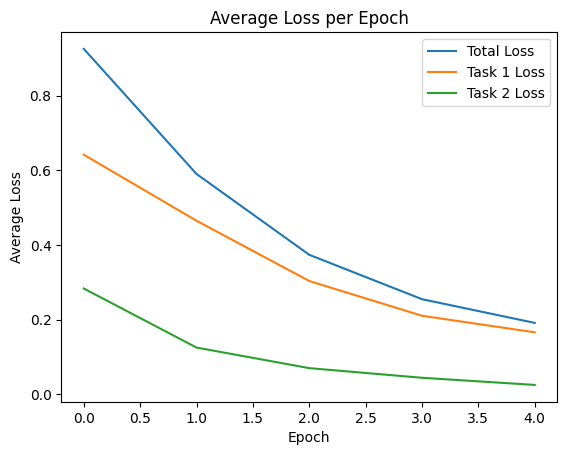

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), avg_loss, label='Total Loss')
plt.plot(np.arange(num_epochs), avg_ucc_loss, label='Task 1 Loss')
plt.plot(np.arange(num_epochs), avg_reddit_loss, label='Task 2 Loss')
plt.legend()
plt.title('Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()

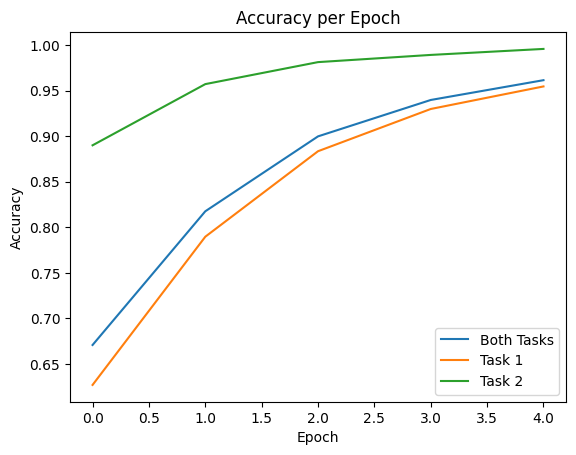

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), train_results['total_accs'], label='Both Tasks')
plt.plot(np.arange(num_epochs), train_results['ucc_accs'], label='Task 1')
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

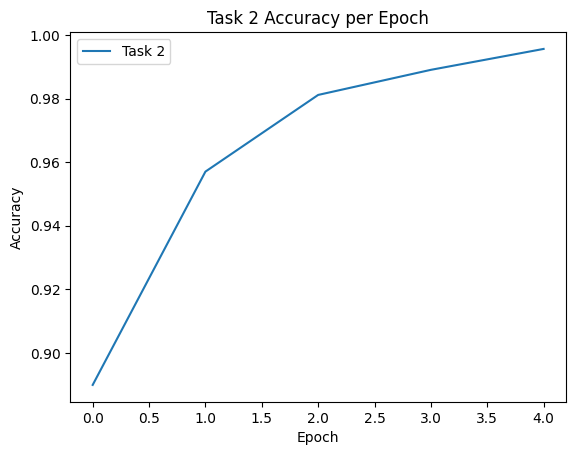

In [ ]:
# Zoom in on Reddit Accuracy
plt.plot(np.arange(num_epochs), train_results['reddit_accs'], label='Task 2')
plt.legend()
plt.title('Task 2 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## STL UCC

In [66]:
def load_results(train_results_file, test_results_file):
    # load training and testing results
    with open(train_results_file, 'rb') as handle:
        train_results = pickle.load(handle)
    with open(test_results_file, 'rb') as handle:
        test_results = pickle.load(handle)

    return train_results, test_results

In [67]:
# Load Model
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/ucc_stl_train_results.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/ucc_stl_test_results.pickle'
train_results, test_results = load_results(train_file, test_file)

In [68]:
# Convert tensors to scalars
epoch_accs = []
for acc in train_results['Accuracy']:
    epoch_accs.append(acc.item())
train_results['Accuracy'] = epoch_accs

In [69]:
all_train_results.append(train_results)
all_test_results.append(test_results)

print(train_results['Loss'])
print('\n', train_results['Accuracy'])

[[0.6709710955619812, 0.7106112837791443, 0.7067075967788696, 0.6330448985099792, 0.6762633919715881, 0.6831797361373901, 0.7000593543052673, 0.7239699363708496, 0.7320947647094727, 0.6549095511436462, 0.7582032680511475, 0.7362192273139954, 0.7063745260238647, 0.7380639314651489, 0.6893349289894104, 0.6608765721321106, 0.6404833793640137, 0.6959840655326843, 0.6598498225212097, 0.6692481637001038, 0.6489312052726746, 0.650982141494751, 0.6556665301322937, 0.6552915573120117, 0.6428308486938477, 0.6149595379829407, 0.660571277141571, 0.6538251042366028, 0.6213153004646301, 0.7072725296020508, 0.6250500082969666, 0.6326012015342712, 0.5806888937950134, 0.6319769620895386, 0.5695158839225769, 0.8090662956237793, 0.6413394808769226, 0.5641821026802063, 0.669334352016449, 0.6139852404594421, 0.582164466381073, 0.9273267984390259, 0.6175760626792908, 0.5770725607872009, 0.5621363520622253, 0.6578397750854492, 0.5439326763153076, 0.6932973265647888, 0.5656153559684753, 0.7340065836906433, 0.

### Plot Loss and Accuracy on Task 1




In [ ]:
avg_loss = [np.mean(epoch_list) for epoch_list in train_results['Loss']]

In [ ]:
print('Avg Total Loss per epoch: ', avg_loss)
print('UCC Accuracy per epoch: ', train_results['Accuracy'])

Avg Total Loss per epoch:  [0.6552157184926632, 0.5849903487511889, 0.5164592771104018, 0.4294412564907678, 0.37971981129360416]
UCC Accuracy per epoch:  [0.6034013628959656, 0.6791383028030396, 0.7460317611694336, 0.8113378882408142, 0.8399093151092529]


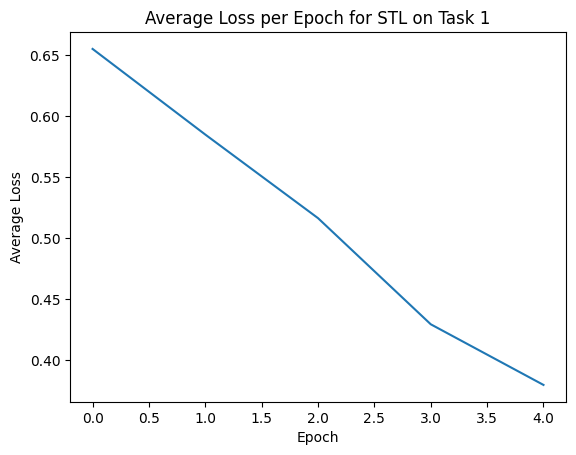

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), avg_loss, label='Loss')
plt.title('Average Loss per Epoch for STL on Task 1')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()

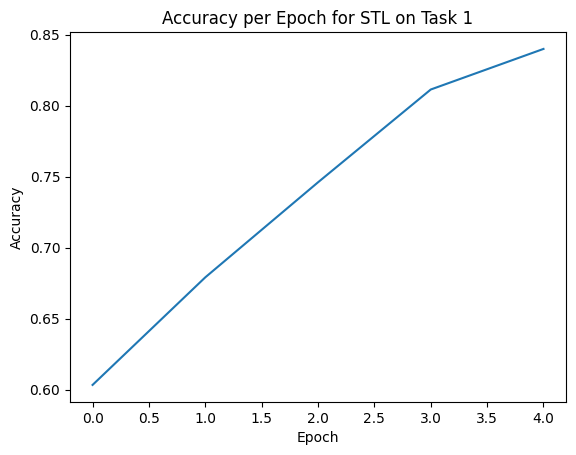

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), train_results['Accuracy'], label='Task 1')
plt.title('Accuracy per Epoch for STL on Task 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## STL Reddit

In [70]:
# Load Model
train_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/reddit_stl_train_results.pickle'
test_file = '/content/drive/My Drive/Colab Notebooks/AISI_project/checkpoints/reddit_stl_test_results.pickle'
train_results, test_results = load_results(train_file, test_file)

In [71]:
# Convert tensors to scalars
epoch_accs = []
for acc in train_results['Accuracy']:
    epoch_accs.append(acc.item())
train_results['Accuracy'] = epoch_accs

In [72]:
all_train_results.append(train_results)
all_test_results.append(test_results)

print(train_results['Loss'])
print('\n', train_results['Accuracy'])

[[0.6498017311096191, 0.687649667263031, 0.6373634338378906, 0.7000095844268799, 0.6857584118843079, 0.8119693994522095, 0.7475844621658325, 0.6807709336280823, 0.6722762584686279, 0.70466148853302, 0.7079836130142212, 0.7411836385726929, 0.651775062084198, 0.7247179746627808, 0.7426877021789551, 0.6682299971580505, 0.7637718915939331, 0.6938779354095459, 0.6312646865844727, 0.6610472202301025, 0.6663303971290588, 0.7070814371109009, 0.7433936595916748, 0.6887022256851196, 0.6580103039741516, 0.5920882225036621, 0.7883275151252747, 0.6641754508018494, 0.6476806402206421, 0.6333605051040649, 0.6074350476264954, 0.6533716320991516, 0.7096661329269409, 0.5265636444091797, 0.46736806631088257, 0.3660549521446228, 0.3439991772174835, 0.2461530864238739, 0.8595673441886902, 1.0674538612365723, 1.0184210538864136, 0.331582635641098, 0.7492717504501343, 0.43538564443588257, 0.1753745973110199, 0.7343425750732422, 0.5060766935348511, 0.7084637880325317, 0.7456738948822021, 0.5870519876480103, 0

### Plot Loss and Accuracy on Task 2


In [ ]:
avg_loss = [np.mean(epoch_list) for epoch_list in train_results['Loss']]

In [ ]:
print('Avg Loss per epoch: ', avg_loss)
print('Reddit Accuracy per epoch: ', train_results['Accuracy'])

Avg Loss per epoch:  [0.3102371198192056, 0.1545031421765646, 0.07590396811324457, 0.04020011243585745, 0.02149571044551577]
Reddit Accuracy per epoch:  [0.8746163845062256, 0.9522139430046082, 0.9758877754211426, 0.9903551340103149, 0.9956159591674805]


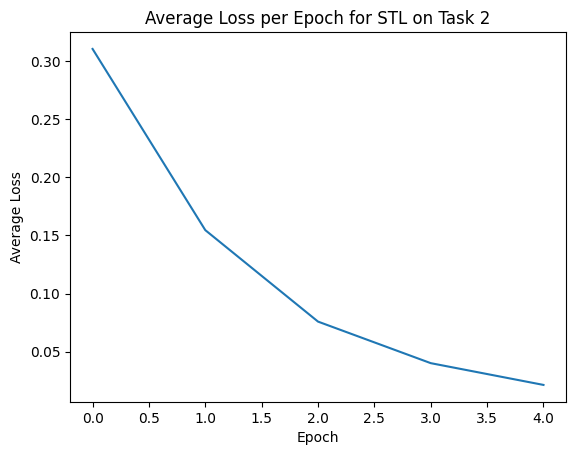

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), avg_loss, label='Loss')
plt.title('Average Loss per Epoch for STL on Task 2')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.show()

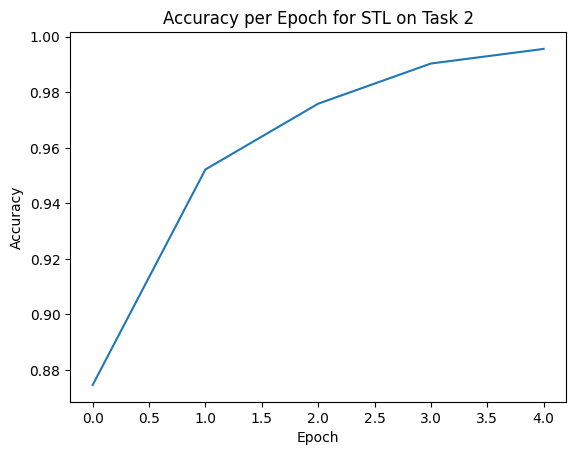

In [ ]:
num_epochs = 5
plt.plot(np.arange(num_epochs), train_results['Accuracy'], label='Accuracy')
plt.title('Accuracy per Epoch for STL on Task 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## Prep results for combined plotting

In [73]:
print(len(all_train_results))
print(len(all_test_results))

6
6


In [76]:
mtl1 = all_train_results[0]
mtl2 = all_train_results[1]
mtl3 = all_train_results[2]
mtl4 = all_train_results[3]
stl5 = all_train_results[4]
stl6 = all_train_results[5]

In [77]:
mtl1_avg_loss = [np.mean(epoch_list) for epoch_list in mtl1['loss_per_epoch']]
mtl1_avg_ucc_loss = [np.mean(epoch_list) for epoch_list in mtl1['ucc_losses']]
mtl1_avg_reddit_loss = [np.mean(epoch_list) for epoch_list in mtl1['reddit_losses']]
mtl1_total_acc = [np.mean(epoch_list) for epoch_list in mtl1['total_accs']]
mtl1_reddit_acc = [np.mean(epoch_list) for epoch_list in mtl1['reddit_accs']]
mtl1_ucc_acc = [np.mean(epoch_list) for epoch_list in mtl1['ucc_accs']]

mtl2_avg_loss = [np.mean(epoch_list) for epoch_list in mtl2['loss_per_epoch']]
mtl2_avg_ucc_loss = [np.mean(epoch_list) for epoch_list in mtl2['ucc_losses']]
mtl2_avg_reddit_loss = [np.mean(epoch_list) for epoch_list in mtl2['reddit_losses']]
mtl2_total_acc = [np.mean(epoch_list) for epoch_list in mtl2['total_accs']]
mtl2_reddit_acc = [np.mean(epoch_list) for epoch_list in mtl2['reddit_accs']]
mtl2_ucc_acc = [np.mean(epoch_list) for epoch_list in mtl2['ucc_accs']]

mtl3_avg_loss = [np.mean(epoch_list) for epoch_list in mtl3['loss_per_epoch']]
mtl3_avg_ucc_loss = [np.mean(epoch_list) for epoch_list in mtl3['ucc_losses']]
mtl3_avg_reddit_loss = [np.mean(epoch_list) for epoch_list in mtl3['reddit_losses']]
mtl3_total_acc = [np.mean(epoch_list) for epoch_list in mtl3['total_accs']]
mtl3_reddit_acc = [np.mean(epoch_list) for epoch_list in mtl3['reddit_accs']]
mtl3_ucc_acc = [np.mean(epoch_list) for epoch_list in mtl3['ucc_accs']]

mtl4_avg_loss = [np.mean(epoch_list) for epoch_list in mtl4['loss_per_epoch']]
mtl4_avg_ucc_loss = [np.mean(epoch_list) for epoch_list in mtl4['ucc_losses']]
mtl4_avg_reddit_loss = [np.mean(epoch_list) for epoch_list in mtl4['reddit_losses']]
mtl4_total_acc = [np.mean(epoch_list) for epoch_list in mtl4['total_accs']]
mtl4_reddit_acc = [np.mean(epoch_list) for epoch_list in mtl4['reddit_accs']]
mtl4_ucc_acc = [np.mean(epoch_list) for epoch_list in mtl4['ucc_accs']]

stl5_avg_loss = [np.mean(epoch_list) for epoch_list in stl5['Loss']]
stl5_ucc_acc = [np.mean(epoch_list) for epoch_list in stl5['Accuracy']]

stl6_avg_loss = [np.mean(epoch_list) for epoch_list in stl6['Loss']]
stl6_reddit_acc = [np.mean(epoch_list) for epoch_list in stl6['Accuracy']]

In [78]:
print(stl5_avg_loss)
print(stl6_avg_loss)

[0.6552157184926632, 0.5849903487511889, 0.5164592771104018, 0.4294412564907678, 0.37971981129360416]
[0.3102371198192056, 0.1545031421765646, 0.07590396811324457, 0.04020011243585745, 0.02149571044551577]


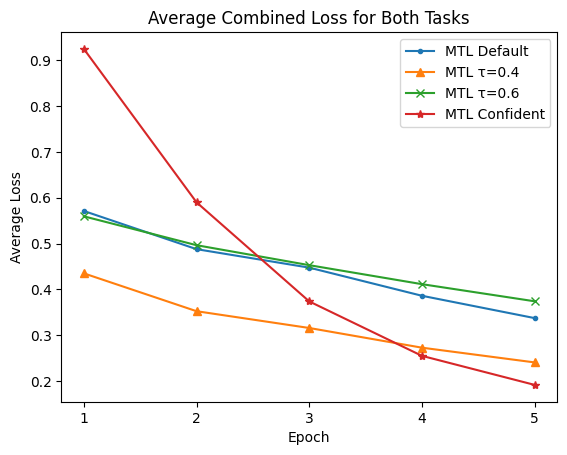

In [79]:
num_epochs = 5
plt.plot(np.arange(1,6,1), mtl1_avg_loss, label='MTL Default', marker='.')
plt.plot(np.arange(1,6,1), mtl2_avg_loss, label='MTL τ=0.4', marker='^')
plt.plot(np.arange(1,6,1), mtl3_avg_loss, label='MTL τ=0.6', marker='x')
plt.plot(np.arange(1,6,1), mtl4_avg_loss, label='MTL Confident', marker='*')
plt.title('Average Combined Loss for Both Tasks')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.xticks(np.arange(1,6,1))
plt.legend()
plt.show()

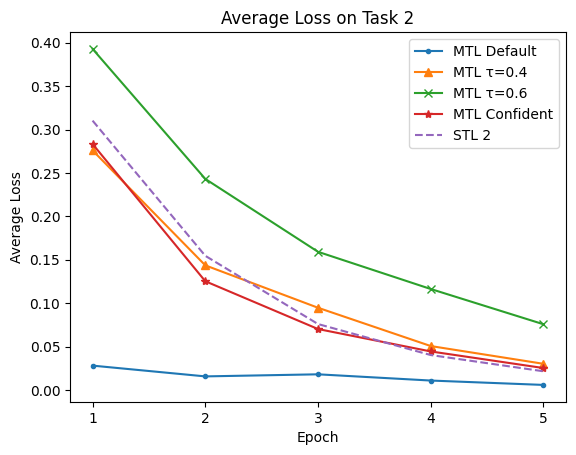

In [86]:
num_epochs = 5
plt.plot(np.arange(1,6,1), mtl1_avg_reddit_loss, label='MTL Default', marker='.')
plt.plot(np.arange(1,6,1), mtl2_avg_reddit_loss, label='MTL τ=0.4', marker='^')
plt.plot(np.arange(1,6,1), mtl3_avg_reddit_loss, label='MTL τ=0.6', marker='x')
plt.plot(np.arange(1,6,1), mtl4_avg_reddit_loss, label='MTL Confident', marker='*')
plt.plot(np.arange(1,6,1), stl6_avg_loss, label='STL 2', linestyle='--')
plt.xticks(np.arange(1,6,1))
plt.title('Average Loss on Task 2')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.show()

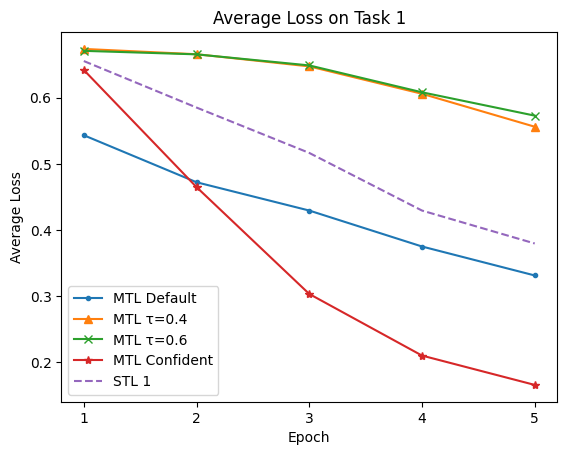

In [81]:
num_epochs = 5
plt.plot(np.arange(1,6,1), mtl1_avg_ucc_loss, label='MTL Default', marker='.')
plt.plot(np.arange(1,6,1), mtl2_avg_ucc_loss, label='MTL τ=0.4', marker='^')
plt.plot(np.arange(1,6,1), mtl3_avg_ucc_loss, label='MTL τ=0.6', marker='x')
plt.plot(np.arange(1,6,1), mtl4_avg_ucc_loss, label='MTL Confident', marker='*')
plt.plot(np.arange(1,6,1), stl5_avg_loss, label='STL 1', linestyle='--')
plt.xticks(np.arange(1,6,1))
plt.title('Average Loss on Task 1')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.show()

# Training Accuracy Plotting for All Models

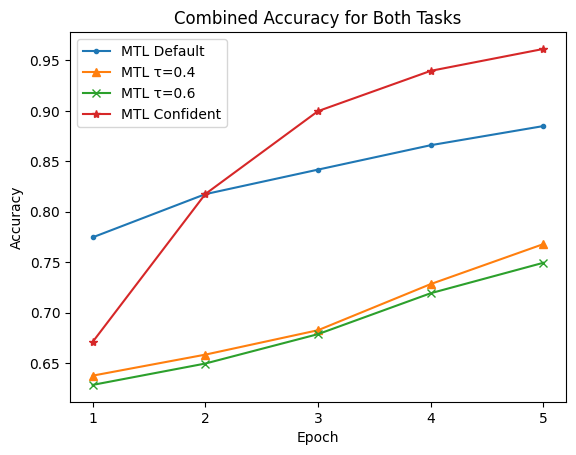

In [83]:
num_epochs = 5
plt.plot(np.arange(1,6,1), mtl1_total_acc, label='MTL Default', marker='.')
plt.plot(np.arange(1,6,1), mtl2_total_acc, label='MTL τ=0.4', marker='^')
plt.plot(np.arange(1,6,1), mtl3_total_acc, label='MTL τ=0.6', marker='x')
plt.plot(np.arange(1,6,1), mtl4_total_acc, label='MTL Confident', marker='*')
plt.xticks(np.arange(1,6,1))
plt.title('Combined Accuracy for Both Tasks')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

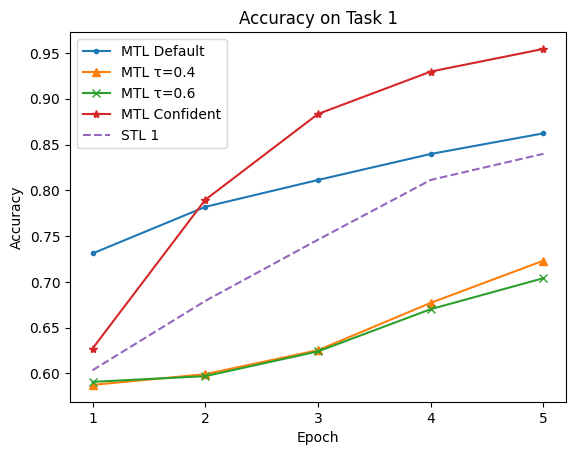

In [84]:
num_epochs = 5
plt.plot(np.arange(1,6,1), mtl1_ucc_acc, label='MTL Default', marker='.')
plt.plot(np.arange(1,6,1), mtl2_ucc_acc, label='MTL τ=0.4', marker='^')
plt.plot(np.arange(1,6,1), mtl3_ucc_acc, label='MTL τ=0.6', marker='x')
plt.plot(np.arange(1,6,1), mtl4_ucc_acc, label='MTL Confident', marker='*')
plt.plot(np.arange(1,6,1), stl5_ucc_acc, label='STL 1', linestyle='--')
plt.xticks(np.arange(1,6,1))
plt.title('Accuracy on Task 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

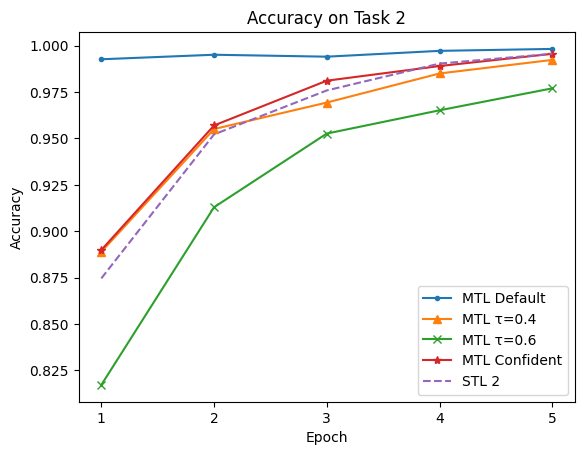

In [87]:
num_epochs = 5
plt.plot(np.arange(1,6,1), mtl1_reddit_acc, label='MTL Default', marker='.')
plt.plot(np.arange(1,6,1), mtl2_reddit_acc, label='MTL τ=0.4', marker='^')
plt.plot(np.arange(1,6,1), mtl3_reddit_acc, label='MTL τ=0.6', marker='x')
plt.plot(np.arange(1,6,1), mtl4_reddit_acc, label='MTL Confident', marker='*')
plt.plot(np.arange(1,6,1), stl6_reddit_acc, label='STL 2', linestyle='--')
plt.xticks(np.arange(1,6,1))
plt.title('Accuracy on Task 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()